In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
transform= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [4]:
train_data = datasets.ImageFolder(
    "../dataset/train",
    transform=transform
)
test_data= datasets.ImageFolder(
    "../dataset/test",
    transform=transform
)

print("Classes:", train_data.classes)
print("Training images:", len(train_data))
print("Validation source images:", len(train_data))
print("Test images:", len(test_data))

Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
Training images: 10109
Validation source images: 10109
Test images: 1279


In [5]:
targets = np.array(
    train_data.targets
)

indices = np.arange(
    len(train_data)
)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=targets    
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

Training samples: 8087
Validation samples: 2022


In [6]:
train_subset = Subset(
    train_data,
    train_indices
)

val_subset = Subset(
    train_data,
    val_indices
)

print(
    "Train subset:",
    len(train_subset)
)

print(
    "Validation subset:",
    len(val_subset)
)

Train subset: 8087
Validation subset: 2022


In [7]:
train_loader= DataLoader(
    train_subset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=16,
    shuffle=False
)

print("DataLoaders created.")

DataLoaders created.


In [8]:
from collections import Counter

train_labels= [
    train_data.targets[i]
    for i in train_indices
]

val_labels = [
    train_data.targets[i]
    for i in val_indices
]

print("TRAIN DISTRIBUTION")
print(Counter(train_labels))

print("\nVALIDATION DISTRIBUTION")
print(Counter(val_labels))

print("\nTEST DISTRIBUTION")
print(Counter(test_data.targets))

TRAIN DISTRIBUTION
Counter({0: 2047, 3: 2046, 1: 2011, 2: 1983})

VALIDATION DISTRIBUTION
Counter({0: 512, 3: 512, 1: 502, 2: 496})

TEST DISTRIBUTION
Counter({2: 640, 3: 448, 0: 179, 1: 12})


In [9]:
class CNNWithBatchNorm(nn.Module):
    def __init__(self, num_classes=4):
        super(CNNWithBatchNorm, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
model = CNNWithBatchNorm(num_classes=4).to(device)

print(model)

CNNWithBatchNorm(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2)

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [12]:
num_epochs = 10

for epoch in range(num_epochs):

    # ----- Training -----
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    # ----- Validation -----
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / val_total
    val_accuracy = val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] Train Loss: 0.9612 Train Acc: 0.5773 Val Loss: 12.5299 Val Acc: 0.2483
Epoch [2/10] Train Loss: 0.7041 Train Acc: 0.6938 Val Loss: 6.8543 Val Acc: 0.2453
Epoch [3/10] Train Loss: 0.6698 Train Acc: 0.6963 Val Loss: 3.4363 Val Acc: 0.2794
Epoch [4/10] Train Loss: 0.6229 Train Acc: 0.7203 Val Loss: 3.2279 Val Acc: 0.4723
Epoch [5/10] Train Loss: 0.6223 Train Acc: 0.7163 Val Loss: 13.2216 Val Acc: 0.2498
Epoch [6/10] Train Loss: 0.5995 Train Acc: 0.7334 Val Loss: 3.9990 Val Acc: 0.4862
Epoch [7/10] Train Loss: 0.5917 Train Acc: 0.7335 Val Loss: 9.2870 Val Acc: 0.2512
Epoch [8/10] Train Loss: 0.5546 Train Acc: 0.7523 Val Loss: 23.1458 Val Acc: 0.2483
Epoch [9/10] Train Loss: 0.5332 Train Acc: 0.7524 Val Loss: 1.4038 Val Acc: 0.4219
Epoch [10/10] Train Loss: 0.5284 Train Acc: 0.7585 Val Loss: 3.2973 Val Acc: 0.3541


In [19]:
model.eval()

print("BatchNorm running statistics:\n")

for name, layer in model.named_modules():
    if isinstance(layer, nn.BatchNorm2d):
        print(name)
        print("Running mean:", layer.running_mean[:5].detach().cpu())
        print("Running var :", layer.running_var[:5].detach().cpu())
        print()

BatchNorm running statistics:

features.1
Running mean: tensor([-0.0159, -0.1173,  0.2278,  1.6840,  1.9997])
Running var : tensor([ 0.1740,  0.4622,  0.1621, 11.8767, 13.7979])

features.5
Running mean: tensor([-1.9333, -4.7715,  2.3348, -3.4155, -7.0527])
Running var : tensor([2.8153, 7.6610, 1.8471, 2.4512, 3.5835])

features.9
Running mean: tensor([-4.9169,  5.2967,  0.8078, -5.0715, -3.8710])
Running var : tensor([1.1063, 1.6636, 2.1441, 1.2793, 8.1209])



In [20]:
# Take one batch from the training loader
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

# Evaluation mode
model.eval()

with torch.no_grad():
    outputs_eval = model(images)
    preds_eval = outputs_eval.argmax(dim=1)

eval_acc = (preds_eval == labels).float().mean().item()

# Training mode
model.train()

with torch.no_grad():
    outputs_train = model(images)
    preds_train = outputs_train.argmax(dim=1)

train_mode_acc = (preds_train == labels).float().mean().item()

print("Accuracy in eval mode :", eval_acc)
print("Accuracy in train mode:", train_mode_acc)

Accuracy in eval mode : 0.3125
Accuracy in train mode: 0.875


In [24]:
model.eval()

images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():

    # First block
    x = model.features[0](images)   # Conv1

    print("=== BatchNorm 1 ===")
    print("Current mean:", x.mean(dim=[0,2,3])[:5].cpu())
    print("Stored mean :", model.features[1].running_mean[:5].cpu())
    print("Current std :", x.std(dim=[0,2,3])[:5].cpu())
    print("Stored std  :", torch.sqrt(model.features[1].running_var[:5]).cpu())

    # Apply BN1 + ReLU + Pool
    x = model.features[1](x)
    x = model.features[2](x)
    x = model.features[3](x)

    # Second block
    x = model.features[4](x)   # Conv2

    print("\n=== BatchNorm 2 ===")
    print("Current mean:", x.mean(dim=[0,2,3])[:5].cpu())
    print("Stored mean :", model.features[5].running_mean[:5].cpu())
    print("Current std :", x.std(dim=[0,2,3])[:5].cpu())
    print("Stored std  :", torch.sqrt(model.features[5].running_var[:5]).cpu())

    # Apply BN2 + ReLU + Pool
    x = model.features[5](x)
    x = model.features[6](x)
    x = model.features[7](x)

    # Third block
    x = model.features[8](x)   # Conv3

    print("\n=== BatchNorm 3 ===")
    print("Current mean:", x.mean(dim=[0,2,3])[:5].cpu())
    print("Stored mean :", model.features[9].running_mean[:5].cpu())
    print("Current std :", x.std(dim=[0,2,3])[:5].cpu())
    print("Stored std  :", torch.sqrt(model.features[9].running_var[:5]).cpu())

=== BatchNorm 1 ===
Current mean: tensor([-0.0254, -0.1209,  0.2349,  1.7326,  2.0504])
Stored mean : tensor([-0.0176, -0.1163,  0.2278,  1.6818,  1.9971])
Current std : tensor([0.3858, 0.6596, 0.4017, 3.3826, 3.6433])
Stored std  : tensor([0.4148, 0.6794, 0.4033, 3.4476, 3.7157])

=== BatchNorm 2 ===
Current mean: tensor([-1.9569, -4.6807,  2.2050, -3.3027, -7.0462])
Stored mean : tensor([-1.9422, -4.7769,  2.3291, -3.4132, -7.0644])
Current std : tensor([1.6381, 2.7621, 1.3326, 1.5894, 1.9158])
Stored std  : tensor([1.6732, 2.7694, 1.3554, 1.5678, 1.8932])

=== BatchNorm 3 ===
Current mean: tensor([-4.8239,  5.4996,  0.4693, -5.1147, -3.8718])
Stored mean : tensor([-4.9143,  5.2957,  0.8148, -5.0680, -3.8684])
Current std : tensor([1.0267, 1.2480, 1.5698, 1.0249, 2.6614])
Stored std  : tensor([1.0505, 1.2803, 1.4617, 1.1274, 2.8417])


In [25]:
print(model)

CNNWithBatchNorm(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2)

In [26]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

# Train mode
model.train()

with torch.no_grad():
    train_output = model(images)
    train_pred = train_output.argmax(dim=1)

# Eval mode
model.eval()

with torch.no_grad():
    eval_output = model(images)
    eval_pred = eval_output.argmax(dim=1)

print("Labels:")
print(labels.cpu().numpy())

print("\nTrain predictions:")
print(train_pred.cpu().numpy())

print("\nEval predictions:")
print(eval_pred.cpu().numpy())

print("\nTrain correct:",
      (train_pred == labels).sum().item(), "/", len(labels))

print("Eval correct:",
      (eval_pred == labels).sum().item(), "/", len(labels))

Labels:
[2 0 3 2 0 2 0 1 0 0 1 0 2 0 3 2]

Train predictions:
[3 0 0 2 3 2 0 1 2 2 1 3 3 0 3 2]

Eval predictions:
[3 0 0 3 0 3 0 0 3 3 0 0 0 0 0 3]

Train correct: 9 / 16
Eval correct: 5 / 16


In [27]:
images, labels = next(iter(train_loader))
images = images.to(device)

def get_bn_outputs(mode):
    model.train() if mode == "train" else model.eval()

    with torch.no_grad():
        x = model.features[0](images)
        bn1 = model.features[1](x)

        x = model.features[2](bn1)
        x = model.features[3](x)

        x = model.features[4](x)
        bn2 = model.features[5](x)

        x = model.features[6](bn2)
        x = model.features[7](x)

        x = model.features[8](x)
        bn3 = model.features[9](x)

    return bn1, bn2, bn3


bn1_train, bn2_train, bn3_train = get_bn_outputs("train")
bn1_eval, bn2_eval, bn3_eval = get_bn_outputs("eval")


for i, (train_bn, eval_bn) in enumerate([
    (bn1_train, bn1_eval),
    (bn2_train, bn2_eval),
    (bn3_train, bn3_eval)
], start=1):

    print(f"\n=== BatchNorm {i} ===")

    print("Train mean:", train_bn.mean().item())
    print("Eval mean :", eval_bn.mean().item())

    print("Train std :", train_bn.std().item())
    print("Eval std  :", eval_bn.std().item())

    print("Mean absolute difference:",
          (train_bn - eval_bn).abs().mean().item())


=== BatchNorm 1 ===
Train mean: -0.11917559802532196
Eval mean : -0.12265381962060928
Train std : 0.9929698705673218
Eval std  : 0.9756738543510437
Mean absolute difference: 0.029512159526348114

=== BatchNorm 2 ===
Train mean: -0.34712880849838257
Eval mean : -0.33794713020324707
Train std : 0.9320288300514221
Eval std  : 0.9224236011505127
Mean absolute difference: 0.03465168923139572

=== BatchNorm 3 ===
Train mean: -0.026260502636432648
Eval mean : -0.025648413226008415
Train std : 1.0455591678619385
Eval std  : 1.0571908950805664
Mean absolute difference: 0.19827628135681152


In [17]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

In [18]:
test_accuracy = accuracy_score(all_labels, all_predictions)
test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")

Test Accuracy: 0.2979
Macro F1 Score: 0.1978


In [15]:
print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_data.classes
))

                      precision    recall  f1-score   support

     Mild Impairment       0.27      0.64      0.38       179
 Moderate Impairment       0.00      0.00      0.00        12
       No Impairment       0.00      0.00      0.00       640
Very Mild Impairment       0.31      0.59      0.41       448

            accuracy                           0.30      1279
           macro avg       0.15      0.31      0.20      1279
        weighted avg       0.15      0.30      0.20      1279



c:\Users\TANISHKA\alzheimer-env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\TANISHKA\alzheimer-env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\TANISHKA\alzheimer-env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


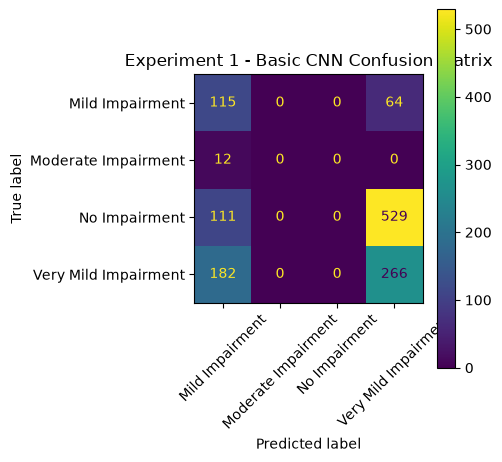

In [16]:
cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_data.classes
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Experiment 1 - Basic CNN Confusion Matrix")
plt.tight_layout()
plt.show()